In [1]:
import numpy as np
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt

In [2]:
#Define quat operators

def hat(v):
    v = np.asarray(v).reshape(3,)
    return np.array([
        [0, -v[2], v[1]],
        [v[2], 0, -v[0]],
        [-v[1], v[0], 0]
    ])

def unhat(S):
    return 0.5 * np.array([S[2,1]-S[1,2],
                           S[0,2]-S[2,0],
                           S[1,0]-S[0,1]])

H = np.vstack([np.zeros((1,3)), np.eye(3)])
T = np.block([
    [np.array([[1]]), np.zeros((1,3))],
    [np.zeros((3,1)), -np.eye(3)]
])

def L(q):
    q = np.asarray(q)
    q0, qv = q[0], q[1:4]
    top = np.hstack([q0, -qv])
    bottom = np.hstack([qv.reshape(3,1), q0*np.eye(3) + hat(qv)])
    return np.vstack([top, bottom])

def R(q):
    q = np.asarray(q)
    return np.block([
        [q[0],            -q[1:4]],
        [q[1:4].reshape(3,1),  q[0]*np.eye(3) - hat(q[1:4])]
    ])

def G(q):
    return L(q) @ H

def Q(q):
    q0, q1, q2, q3 = q
    return np.array([
        [1-2*(q2**2+q3**2), 2*(q1*q2-q0*q3), 2*(q0*q2+q1*q3)],
        [2*(q1*q2+q0*q3), 1-2*(q1**2+q3**2), 2*(q2*q3-q0*q1)],
        [2*(q1*q3-q0*q2), 2*(q0*q1+q2*q3), 1-2*(q1**2+q2**2)]
    ])
    
def expq(phi):
    phi = np.asarray(phi)
    theta = np.linalg.norm(phi)
    if theta < 1e-8:
        return np.hstack([1.0, phi])
    return np.hstack([np.cos(theta), phi * np.sin(theta)/theta])


In [3]:
def dynamics(x):
    q = x[0:4] / np.linalg.norm(x[0:4])
    w = x[4:7]
    qdot = 0.5 * G(q) @ w
    wdot = -np.linalg.inv(J) @ (hat(w) @ J @ w)
    return np.hstack([qdot, wdot])

In [4]:
def rkstep(J, x, h):
    f1 = dynamics(x)
    f2 = dynamics(x + 0.5*h*f1)
    f3 = dynamics(x + 0.5*h*f2)
    f4 = dynamics(x + h*f3)
    xn = x + (h/6)*(f1 + 2*f2 + 2*f3 + f4)
    xn[0:4] /= np.linalg.norm(xn[0:4])
    return xn

In [5]:
J = np.diag([132.56, 101.64, 89.61]) #from HW1

In [6]:
h = 0.1 #time step
n = 600 #number of time steps
tf = n*h #final time

#sample random initial attitude
q0 = np.random.randn(4)
q0 = q0/np.linalg.norm(q0)

#sample random angular velocity
ω0 = 0.1*np.random.randn(3)

#sample random gyro bias
# β0 = 0.3*np.random.randn(3)

x0 = np.hstack([q0, ω0])

In [7]:
xtraj = np.zeros((7, n))
xtraj[:,0] = x0
for k in range(n-1):
    xtraj[:,k+1] = rkstep(J, xtraj[:,k], h)

<h3>  Noise and Sensor Measurements  <h3>

In [8]:
#### [ADD UNITS IN COMMENTS LATER]
#Number of sensors
m_sun = 1
m_st = 1

#Sun sensor parameters
r_sun_N = np.array([1.0, 0.0, 0.0])  #Inertial Sun direction
r_sun_N = r_sun_N / np.linalg.norm(r_sun_N)

rng = np.random.default_rng(1)

scale_std_sun = 2e-3
misalign_std_sun = 1e-3

M_sun = np.eye(3)
M_sun += np.diag(scale_std_sun * rng.standard_normal(3))

Mis_sun = misalign_std_sun * rng.standard_normal((3,3))
np.fill_diagonal(Mis_sun, 0.0)
M_sun += Mis_sun

b_sun = np.deg2rad(np.array([0.02, -0.01, 0.01]))

sigma_sun = np.deg2rad(1.0) #from 0.1 to 1.0
W_sun = (sigma_sun**2) * np.eye(3)


#Star tracker parameters
sigma_st_arcsec = 50.0 #from 1.0 to 20.0
sigma_st = (sigma_st_arcsec / 3600.0) * np.pi / 180.0

W_st_single = (sigma_st**2) * np.eye(3)
W_st = (sigma_st**2) * np.eye(3*m_st)


#Gyro parameters
scale_std_gyro = 5e-4
misalign_std_gyro = 1e-3

Mgyro = np.eye(3)
Mgyro += np.diag(scale_std_gyro * rng.standard_normal(3))

Mis_gyro = misalign_std_gyro * rng.standard_normal((3,3))
np.fill_diagonal(Mis_gyro, 0.0)
Mgyro += Mis_gyro

sigma_gyro = np.deg2rad(0.5) #0.02 to 0.1
Wgyro = (sigma_gyro**2) * np.eye(3)

sigma_bias_rw = np.deg2rad(0.05) #0.001 to 0.012
Wbias = (sigma_bias_rw**2) * h * np.eye(3)


In [9]:
#Generate sun sensor measurements
ysun = np.zeros((3, n))
sqrtW_sun = sqrtm(W_sun)

for k in range(n):
    qk = xtraj[0:4, k]
    yideal = Q(qk).T @ r_sun_N
    y = M_sun @ yideal + b_sun + sqrtW_sun @ np.random.randn(3)
    y = y / np.linalg.norm(y)
    ysun[:, k] = y

#Generate star-tracker measurements
ytraj_st = np.zeros((4*m_st, n))
sqrtW_st = sqrtm(W_st)

for k in range(n):
    qk = xtraj[0:4, k]
    yk = np.zeros((4, m_st))

    wk = (sqrtW_st @ np.random.randn(3*m_st)).reshape((3, m_st), order='F')

    # [CHANGE "ell" TO "l"]
    for ell in range(m_st):
        yk[:, ell] = L(qk) @ expq(wk[:, ell])
        yk[:, ell] = yk[:, ell] / np.linalg.norm(yk[:, ell])

    ytraj_st[:, k] = yk.reshape(4*m_st, order='F')

#Generate gyro measurements
ygyro = np.zeros((3, n))

b0 = np.deg2rad(np.array([0.05, -0.03, 0.02])) #initial gyro bias
btraj = np.zeros((3, n))
btraj[:, 0] = b0

sqrtWgyro = sqrtm(Wgyro)
sqrtWbias = sqrtm(Wbias)

for k in range(n):
    if k > 0:
        btraj[:, k] = btraj[:, k-1] + sqrtWbias @ np.random.randn(3)

    omega_true = xtraj[4:7, k]
    ygyro[:, k] = Mgyro @ omega_true + btraj[:, k] + sqrtWgyro @ np.random.randn(3)

In [10]:
""" V = np.block([
    [0.25 * h**2 * Wgyro,        np.zeros((3,3))],
    [np.zeros((3,3)),            Wbias]
]) """
V = np.block([
    [0.25 * h**2 * Wgyro * 10,  np.zeros((3,3))],
    [np.zeros((3,3)),            Wbias * 10]
])
W = np.block([
    [W_st,                  np.zeros((3*m_st, 3))],
    [np.zeros((3, 3*m_st)), W_sun]
])

In [11]:
# # generate noisy gyro measurements
# gyro = np.zeros((3, n))
# for k in range(n):
#     gyro[:,k] = xtraj[4:7,0] + β0 + sqrtm(V[3:6,3:6]) @ np.random.randn(3)

In [12]:
# #Generate noisy star-tracker measurements
# ytraj = np.zeros((4*m,n))
# for k in range(n):
#     qk = xtraj[0:4,k]
#     wk = sqrtm(W) @ np.random.randn(3*m)
#     wk = wk.reshape(3,m)
#     yk = np.zeros((4,m))
#     for l in range(m):
#         yk[:,l] = L(qk) @ expq(wk[:,l])
#     ytraj[:,k] = yk.flatten()

In [13]:
def state_prediction(x,u,h):
    q = x[0:4]
    beta = x[4:7]
    omega = u - beta
    delta_q = expq(0.5*h*omega)
    qn = L(q) @ delta_q
    qn /= np.linalg.norm(qn)
    return np.hstack([qn, beta])

def state_prediction_deriv(x,u,h):
    q = x[0:4]
    beta = x[4:7]
    omega = u - beta
    delta_q = expq(0.5*h*omega)
    qn = L(q) @ delta_q
    A = np.block([
        [G(qn).T @ R(delta_q) @ G(q), -0.5*h * (G(qn).T @ G(qn))],
        [np.zeros((3,3)), np.eye(3)]
    ])
    return A

In [14]:
def innovation_combined(x,y_st, y_sun):
    q = x[0:4]

    #Star tracker
    yk_st = y_st.reshape((4, m_st), order='F')
    z_st = np.zeros((3, m_st))
    for ell in range(m_st):
        z_st[:, ell] = G(q).T @ yk_st[:, ell]

    #Sun sensor
    yhat_sun = Q(q).T @ r_sun_N
    z_sun = y_sun - yhat_sun

    return np.hstack([z_st.reshape(3*m_st, order='F'), z_sun])

def innovation_deriv_combined(x,y_st, y_sun):
        q = x[0:4]

        #Star tracker
        yk_st = y_st.reshape((4, m_st), order='F')
        C_st = np.zeros((3*m_st, 6))
        for ell in range(m_st):
            C_st[3*ell:3*ell+3, 0:3] = H.T @ R(yk_st[:, ell]) @ T @ G(q)

        #Sun sensor
        yhat_sun = Q(q).T @ r_sun_N
        C_sun = np.zeros((3, 6))
        C_sun[:, 0:3] = hat(yhat_sun)

        return np.vstack([C_st, C_sun])

In [15]:
#Filter Initialization
xfilt = np.zeros((7, n))
xfilt[0:4, 0] = q0 + 0.01*np.random.randn(4)
xfilt[0:4, 0] /= np.linalg.norm(xfilt[0:4, 0])

xfilt[4:7, 0] = np.zeros(3) #bias estimate

#covariance
P = np.zeros((6, 6, n))
P[:,:,0] = np.diag([
    (5*np.pi/180)**2,
    (5*np.pi/180)**2,
    (5*np.pi/180)**2,
    (0.01)**2,
    (0.01)**2,
    (0.01)**2
])

In [16]:
for k in range(n-1):
    #Prediction
    xpred = state_prediction(xfilt[:,k], ygyro[:,k], h)
    A = state_prediction_deriv(xfilt[:,k], ygyro[:,k], h)
    Ppred = A @ P[:,:,k] @ A.T + V

    #Innovation (using both sensors)
    z = innovation_combined(xpred, ytraj_st[:, k+1], ysun[:, k+1])
    #print(np.linalg.norm(z))
    C = innovation_deriv_combined(xpred, ytraj_st[:, k+1], ysun[:, k+1])

    S = C @ Ppred @ C.T + W

    #Kalman gain
    K = Ppred @ C.T @ np.linalg.inv(S)

    #Update
    delta_x = -K @ z
    phi = delta_x[0:3]
    delta_q = np.hstack([np.sqrt(max(0, 1 - phi.T @ phi)), phi])


    xfilt[:,k+1] = np.hstack([L(xpred[0:4]) @ delta_q, xpred[4:7] + delta_x[3:6]])
    xfilt[0:4,k+1] /= np.linalg.norm(xfilt[0:4,k+1])
    P[:,:,k+1] = (np.eye(6) - K@C) @ Ppred @ (np.eye(6) - K@C).T + K @ W @ K.T

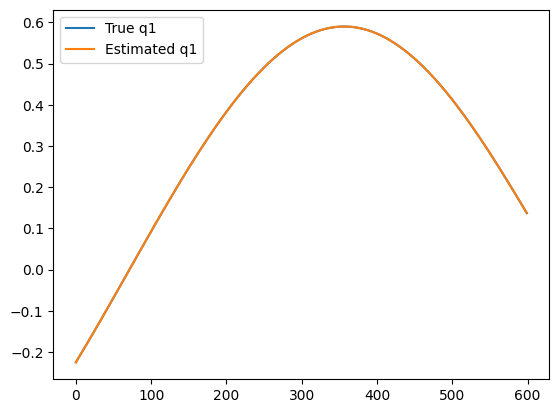

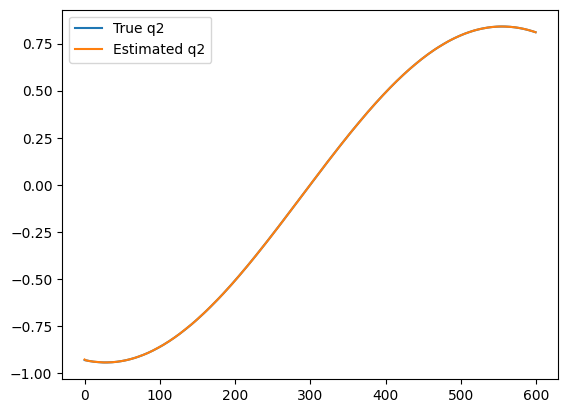

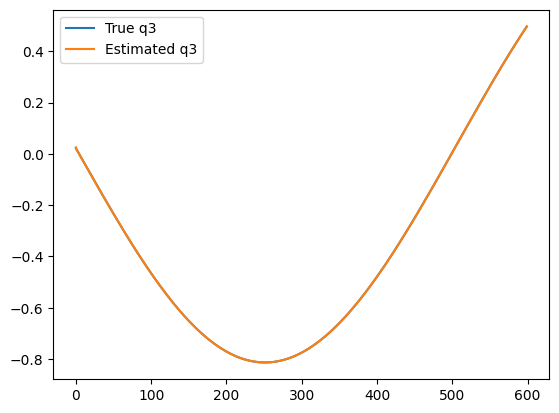

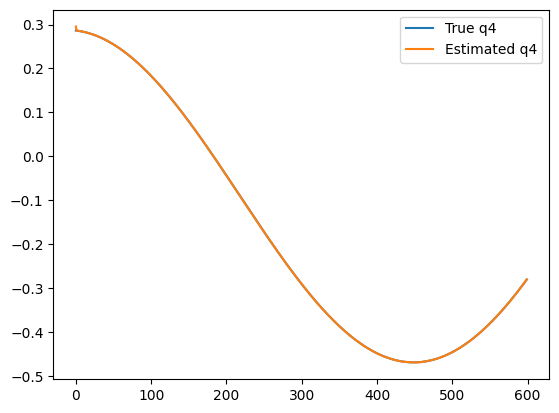

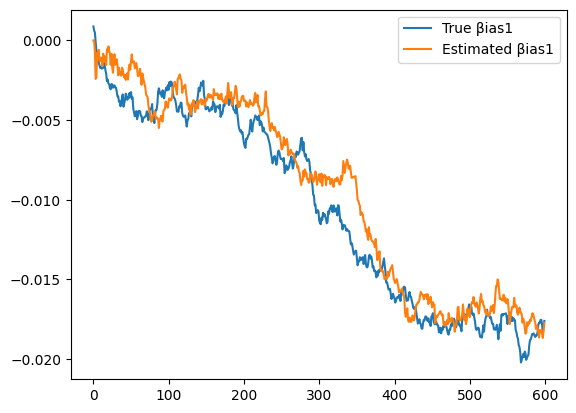

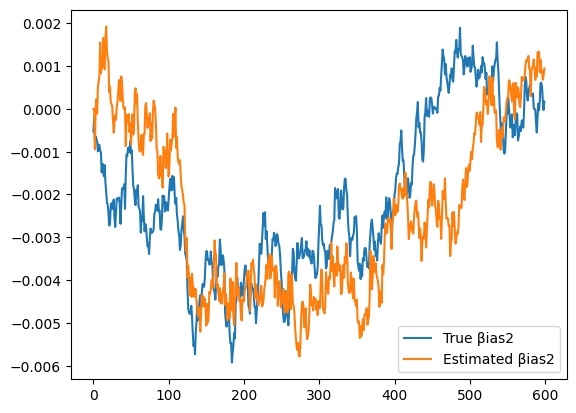

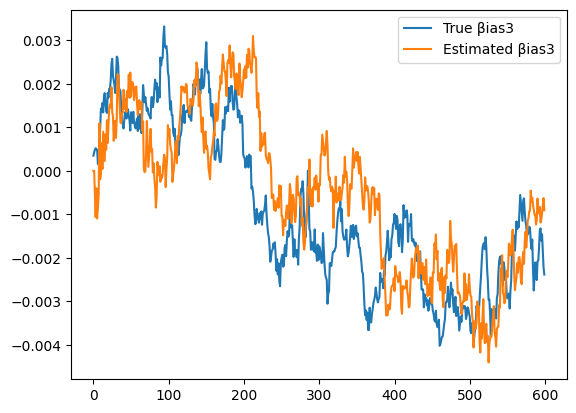

In [17]:
for i in range(4):
    plt.figure()
    plt.plot(xtraj[i,:], label=f'True q{i+1}')
    plt.plot(xfilt[i,:], label=f'Estimated q{i+1}')
    plt.legend()
    plt.show()

for i in range(3):
    plt.figure()
    plt.plot(btraj[i,:], label=f'True βias{i+1}')
    plt.plot(xfilt[4+i,:], label=f'Estimated βias{i+1}')
    plt.legend()
    plt.show()

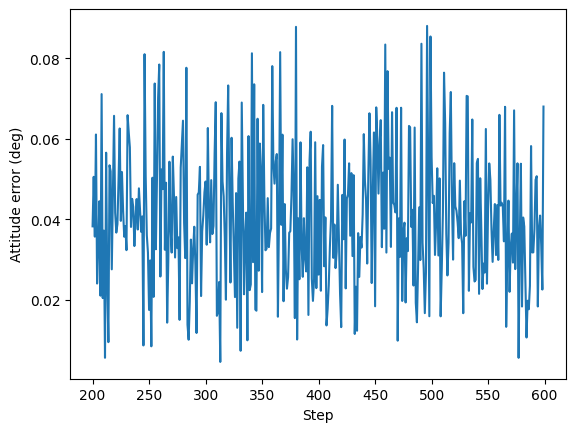

In [18]:
# Compute quaternion error at each step
err = np.zeros(n)
for k in range(n):
    q_true = xtraj[0:4, k]
    q_est  = xfilt[0:4, k]
    # error quaternion
    dq = L(q_true).T @ q_est
    dq /= np.linalg.norm(dq)
    # angle error in degrees
    err[k] = np.degrees(2 * np.arccos(np.clip(abs(dq[0]), 0, 1)))

plt.plot(range(200, 600), err[200:600])
plt.ylabel('Attitude error (deg)')
plt.xlabel('Step')
plt.show()